In [1]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import holidays as hld

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [3]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [4]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

### Valores atipicos

In [5]:
precios_negativos_cero = uber[uber["fare_amount"] <= 0]
print(f"Viajes con costos negativos: {precios_negativos_cero["passenger_count"].count()}") # hay 17 valores negativos y 5 con valor 0

Viajes con costos negativos: 22


In [6]:
""""
Reemplamamos los valores de las columnas de latitud y longitud que son 0 por NaN
"""
uber['pickup_latitude'] = uber['pickup_latitude'].replace(0, np.nan)
uber['pickup_longitude'] = uber['pickup_longitude'].replace(0, np.nan)
uber['dropoff_latitude'] = uber['dropoff_latitude'].replace(0, np.nan)
uber['dropoff_longitude'] = uber['dropoff_longitude'].replace(0, np.nan)

# eliminamos con costos menores o iguales que 0
uber = uber[
    (uber["fare_amount"] > 0)
]

# Reemplamos el valor atipico del precio, por NaN

uber['fare_amount'] = uber['fare_amount'].replace(uber['fare_amount'].max(), np.nan)

In [7]:
porcentaje_eliminados = round((200000- len(uber)) / 200000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 0.01% de los datos


### Valores Nulos

In [8]:
uber.isna().sum()

key                     0
date                    0
fare_amount             1
pickup_datetime         0
pickup_longitude     3785
pickup_latitude      3781
dropoff_longitude    3762
dropoff_latitude     3756
passenger_count         0
dtype: int64

In [9]:
# # Remplazamos los valores null de las columnas de latitud y longitud por la mediana de los valores de la columna

# uber['pickup_latitude'] = uber['pickup_latitude'].fillna(uber['pickup_latitude'].median())
# uber['pickup_longitude'] = uber['pickup_longitude'].fillna(uber['pickup_longitude'].median())
# uber['dropoff_latitude'] = uber['dropoff_latitude'].fillna(uber['dropoff_latitude'].median())
# uber['dropoff_longitude'] = uber['dropoff_longitude'].fillna(uber['dropoff_longitude'].median())

### Creación de nuevas variables

In [10]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [11]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

In [12]:
uber["hora"] = uber["pickup_datetime"].dt.hour
uber["fecha"] = uber["pickup_datetime"].dt.date
uber["día"] = uber["pickup_datetime"].dt.day_name()

us_holidays = hld.US()
us_holidays = hld.country_holidays('US')

nyse_holidays = hld.NYSE()
nyse_holidays = hld.financial_holidays('NYSE')

uber["feriado"] = uber["fecha"].apply(lambda x: x in us_holidays or x in nyse_holidays)

### Graficos

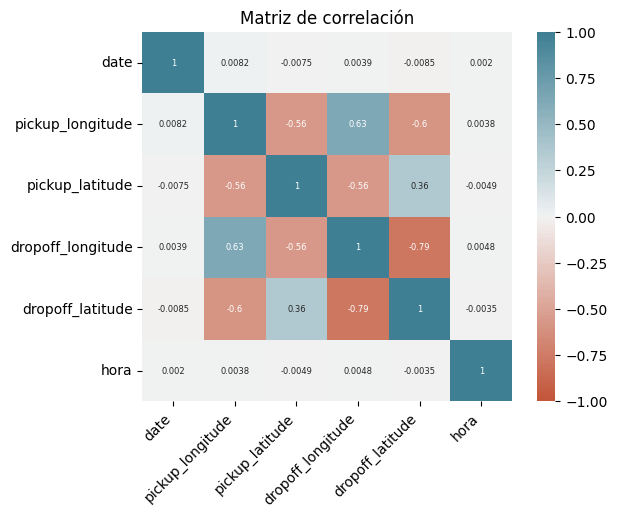

In [13]:
columnas_sin_corr = ["fare_amount", "passenger_count", "distancia", "día", "feriado","key","fecha","pickup_datetime"]
matriz = uber.drop(columns=columnas_sin_corr)
corr = matriz.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title("Matriz de correlación")
plt.show()